In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv('../data/cleaned_news.csv')

X_train, X_test, y_train, y_test = train_test_split(
    data['text_clean'],
    data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train size: 35345, Test size: 8837
label
Fake News    0.515264
Real News    0.484736
Name: proportion, dtype: float64
label
Fake News    0.515333
Real News    0.484667
Name: proportion, dtype: float64


In [16]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35345, 5000)
(8837, 5000)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Fake News       0.98      0.97      0.98      4554
   Real News       0.97      0.98      0.98      4283

    accuracy                           0.98      8837
   macro avg       0.98      0.98      0.98      8837
weighted avg       0.98      0.98      0.98      8837



In [19]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes ===
              precision    recall  f1-score   support

   Fake News       0.93      0.93      0.93      4554
   Real News       0.93      0.93      0.93      4283

    accuracy                           0.93      8837
   macro avg       0.93      0.93      0.93      8837
weighted avg       0.93      0.93      0.93      8837



In [21]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_real_idx = np.argsort(coefs)[-15:][::-1]
top_fake_idx = np.argsort(coefs)[:15]

print("Top words predicting REAL:")
for idx in top_real_idx:
    print(f"  {feature_names[idx]}: {coefs[idx]:.3f}")

print("\nTop words predicting FAKE:")
for idx in top_fake_idx:
    print(f"  {feature_names[idx]}: {coefs[idx]:.3f}")

Top words predicting REAL:
  said: 17.387
  president donald: 8.136
  wednesday: 6.149
  tuesday: 5.705
  thursday: 5.366
  friday: 5.106
  monday: 4.500
  representative: 4.168
  told: 4.008
  president barack: 3.902
  edt: 3.876
  presidential: 3.787
  told reporter: 3.575
  said statement: 3.533
  spokesman: 3.428

Top words predicting FAKE:
  read: -6.627
  gop: -6.419
  president trump: -5.954
  mr: -5.385
  even: -4.948
  hillary: -4.742
  president obama: -4.537
  obama: -4.535
  rep: -4.526
  america: -4.520
  sen: -4.511
  wire: -4.502
  not: -4.460
  watch: -4.408
  com: -4.345


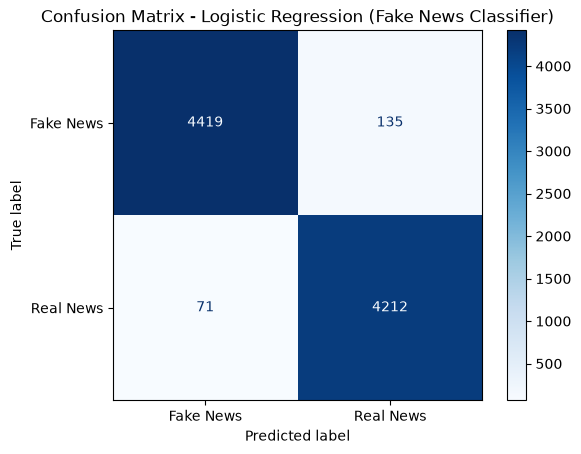

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression (Fake News Classifier)')
plt.show()